# 02 — Dataset Generation & Inspection

Generate a reproducible dataset of sequences from a 3-state Markov chain
whose transition matrix is drawn from a symmetric Dirichlet distribution,
save it to disk, and inspect its statistical properties.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from markov_chain import (
    sample_sequences,
    sample_transition_matrix,
    stationary_distribution,
)
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## Generate sequences

In [2]:
# -- Papermill parameters -----------------------------------------------------
DATA_DIR = "../data"  # output directory (string for papermill)
DGP_REGIME = (
    "two_anchor_far"  # single | two_far | two_close | two_anchor_far | two_anchor_close
)
N_SEQUENCES = 10_000
MAX_SEQ_LEN = 32
SEED = 0
N_STATES = 30
# Symmetric Dirichlet for symmetric regimes: pass np.full(N_STATES, c) for concentration c.
# For a targeted pi, pass c * pi_target.
ALPHA = np.full(N_STATES, 1.0)
PAD_ID = -1
FAR_MIN_FRO = 0.5
CLOSE_MAX_FRO = 0.2
MAX_PAIR_TRIES = 10_000

# Asymmetric Dirichlet controls for anchored regimes.
ALPHA_BACKGROUND = 0.05
ALPHA_ANCHOR_BONUS = 8.0
ALPHA_ANCHOR_NEIGHBOR_BONUS = 1.0
ANCHOR_FAR_MIN_GAP = max(2, N_STATES // 3)
ANCHOR_CLOSE_MAX_GAP = max(1, N_STATES // 8)

In [3]:
# Parameters
DATA_DIR = "/Users/ashrafahmed/workspace/slt-deep/projects/markov-chain-learning/experiments/two-mixed-chains/data/single"
DGP_REGIME = "single"
SEED = 0
N_SEQUENCES = 200
MAX_SEQ_LEN = 16

In [4]:
# -- Post-papermill coercions -------------------------------------------------
DATA_DIR = Path(DATA_DIR)
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Data dir:", DATA_DIR.resolve())

Data dir: /Users/ashrafahmed/workspace/slt-deep/projects/markov-chain-learning/experiments/two-mixed-chains/data/single


In [5]:
def _anchor_alpha_vector(n_states, anchor):
    """Build a Dirichlet alpha vector targeting a multinomial concentrated at anchor.

    Sets alpha = c * pi_target where pi_target places most mass at `anchor` and
    its immediate neighbours, with a small background on all other states.
    The sampled T's stationary distribution will concentrate near pi_target = alpha / alpha.sum().
    """
    alpha_vec = np.full(n_states, ALPHA_BACKGROUND, dtype=float)
    alpha_vec[anchor] += ALPHA_ANCHOR_BONUS

    # Give immediate neighbors a mild lift for smoother multimodal shape.
    if anchor - 1 >= 0:
        alpha_vec[anchor - 1] += ALPHA_ANCHOR_NEIGHBOR_BONUS
    if anchor + 1 < n_states:
        alpha_vec[anchor + 1] += ALPHA_ANCHOR_NEIGHBOR_BONUS

    return alpha_vec


def _sample_anchor_pair(regime, rng):
    """Sample anchor indices according to a far/close separation criterion."""
    for _ in range(MAX_PAIR_TRIES):
        a, b = rng.choice(N_STATES, size=2, replace=False)
        gap = abs(int(a) - int(b))
        if regime == "two_anchor_far" and gap >= ANCHOR_FAR_MIN_GAP:
            return int(a), int(b), int(gap)
        if regime == "two_anchor_close" and gap <= ANCHOR_CLOSE_MAX_GAP:
            return int(a), int(b), int(gap)
    raise RuntimeError(
        f"{regime}: could not find anchors under gap constraint in {MAX_PAIR_TRIES} tries"
    )


def _build_anchored_pair(regime):
    rng = np.random.default_rng(SEED)
    a0, a1, gap = _sample_anchor_pair(regime, rng)

    alpha0 = _anchor_alpha_vector(N_STATES, a0)
    alpha1 = _anchor_alpha_vector(N_STATES, a1)

    # Each chain uses its own 1-D alpha vector (same alpha for every row within the chain).
    T0 = sample_transition_matrix(n_states=N_STATES, alpha=alpha0, n=1, rng=SEED + 777)
    T1 = sample_transition_matrix(n_states=N_STATES, alpha=alpha1, n=1, rng=SEED + 778)
    Ts_local = np.stack([T0, T1])

    info = {
        "n_chains": 2,
        "anchors": (a0, a1),
        "anchor_gap": gap,
        "alpha_background": ALPHA_BACKGROUND,
        "alpha_anchor_bonus": ALPHA_ANCHOR_BONUS,
        "alpha_anchor_neighbor_bonus": ALPHA_ANCHOR_NEIGHBOR_BONUS,
    }
    return Ts_local, info


def build_transition_matrices():
    """Return (Ts, regime_info) with Ts shaped (n_chains, N_STATES, N_STATES)."""
    if DGP_REGIME == "single":
        Ts_local = sample_transition_matrix(
            n_states=N_STATES, alpha=ALPHA, n=1, rng=SEED
        )
        Ts_local = Ts_local[np.newaxis]  # (S, S) -> (1, S, S)
        info = {"n_chains": 1, "alpha_mode": "symmetric"}
    elif DGP_REGIME == "two_far":
        for attempt in range(MAX_PAIR_TRIES):
            T2 = sample_transition_matrix(
                n_states=N_STATES, alpha=ALPHA, n=2, rng=SEED + attempt
            )
            fro = float(np.linalg.norm(T2[0] - T2[1], ord="fro"))
            if fro >= FAR_MIN_FRO:
                Ts_local = T2
                info = {
                    "n_chains": 2,
                    "frobenius_distance": fro,
                    "alpha_mode": "symmetric",
                }
                break
        else:
            raise RuntimeError(
                f"two_far: no pair with fro>={FAR_MIN_FRO} in {MAX_PAIR_TRIES} tries"
            )
    elif DGP_REGIME == "two_close":
        for attempt in range(MAX_PAIR_TRIES):
            T2 = sample_transition_matrix(
                n_states=N_STATES, alpha=ALPHA, n=2, rng=SEED + attempt
            )
            fro = float(np.linalg.norm(T2[0] - T2[1], ord="fro"))
            if fro <= CLOSE_MAX_FRO:
                Ts_local = T2
                info = {
                    "n_chains": 2,
                    "frobenius_distance": fro,
                    "alpha_mode": "symmetric",
                }
                break
        else:
            raise RuntimeError(
                f"two_close: no pair with fro<={CLOSE_MAX_FRO} in {MAX_PAIR_TRIES} tries"
            )
    elif DGP_REGIME in {"two_anchor_far", "two_anchor_close"}:
        Ts_local, info = _build_anchored_pair(DGP_REGIME)
        info["alpha_mode"] = "asymmetric"
    else:
        raise ValueError(f"Unknown DGP_REGIME: {DGP_REGIME!r}")
    return Ts_local, info


Ts, regime_info = build_transition_matrices()
N_CHAINS = Ts.shape[0]
pis = np.stack([stationary_distribution(Ts[k]) for k in range(N_CHAINS)], axis=0)

print(f"DGP regime : {DGP_REGIME}  ({N_CHAINS} chain(s))")
print(f"Regime info: {regime_info}")

# Concentration and separation diagnostics for the stationary distributions.
entropies = -np.sum(pis * np.log(pis + 1e-12), axis=1)
top1_mass = np.max(pis, axis=1)
top_k = min(5, N_STATES)
print("\nStationary diagnostics:")
for i in range(N_CHAINS):
    top_idx = np.argsort(pis[i])[::-1][:top_k]
    top_pairs = [(int(s), float(pis[i, s])) for s in top_idx]
    print(
        f"  chain {i}: entropy={entropies[i]:.4f}, top1_mass={top1_mass[i]:.4f}, "
        f"top_states={top_pairs}"
    )

if N_CHAINS > 1:
    for i in range(N_CHAINS):
        for j in range(i + 1, N_CHAINS):
            tv = 0.5 * np.abs(pis[i] - pis[j]).sum()
            print(f"  TV(pi[{i}], pi[{j}]) = {tv:.4f}")

DGP regime : single  (1 chain(s))
Regime info: {'n_chains': 1, 'alpha_mode': 'symmetric'}

Stationary diagnostics:
  chain 0: entropy=3.3870, top1_mass=0.0476, top_states=[(25, 0.04761563932024856), (9, 0.04539635215132928), (5, 0.04069301463933442), (22, 0.04029464093205961), (4, 0.040100701594102804)]


In [6]:
# Sample sequences using the stationary distribution of the selected chain.

seqs_lengths = np.random.choice(np.arange(2, MAX_SEQ_LEN), N_SEQUENCES)
chain_to_sample = np.random.choice(np.arange(N_CHAINS), N_SEQUENCES)
sequences_np = np.full((N_SEQUENCES, MAX_SEQ_LEN), PAD_ID, dtype=np.int64)

for i in tqdm(range(N_SEQUENCES), desc="Sampling sequences"):
    chain_idx = chain_to_sample[i]
    seq_len = seqs_lengths[i]
    x = sample_sequences(
        Ts[chain_idx], n=1, seq_len=seq_len, prior=pis[chain_idx], rng=SEED + i
    )
    sequences_np[i, : len(x[0])] = x[0]

sequences = torch.from_numpy(sequences_np).long()

print(f"sequences: {sequences.shape}  dtype={sequences.dtype}")
print("First 10 sequences:")
print(sequences[:10])
print(f"PAD count: {(sequences == PAD_ID).sum().item():,}")

Sampling sequences:   0%|          | 0/200 [00:00<?, ?it/s]

sequences: torch.Size([200, 16])  dtype=torch.int64
First 10 sequences:
tensor([[19,  8,  2,  1, 22, 26, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [15, 29,  6, 29, 10, 13, 22, 12, 17,  0, 19, -1, -1, -1, -1, -1],
        [ 7, 15, 27,  3, 12, 22, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 2, 10, 25, 17,  4, 12, 15,  6, -1, -1, -1, -1, -1, -1, -1, -1],
        [28, 15, 29,  2, 19, 11, 24,  5, 27, 14, 28, 13,  9, 25, 29, -1],
        [24, 21, 13,  6,  2, 13,  8,  2,  4, 29, 21,  7, 19, 28, 25, -1],
        [16,  9, 14, 11, 28, 18, 20, 12, 20,  3,  0, 24,  2, 29, -1, -1],
        [18, 27, 24, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 9, 29, 10, 25, 25, 14, 12, 12,  5, 14, -1, -1, -1, -1, -1, -1],
        [25, 14, 20, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]])
PAD count: 1,553


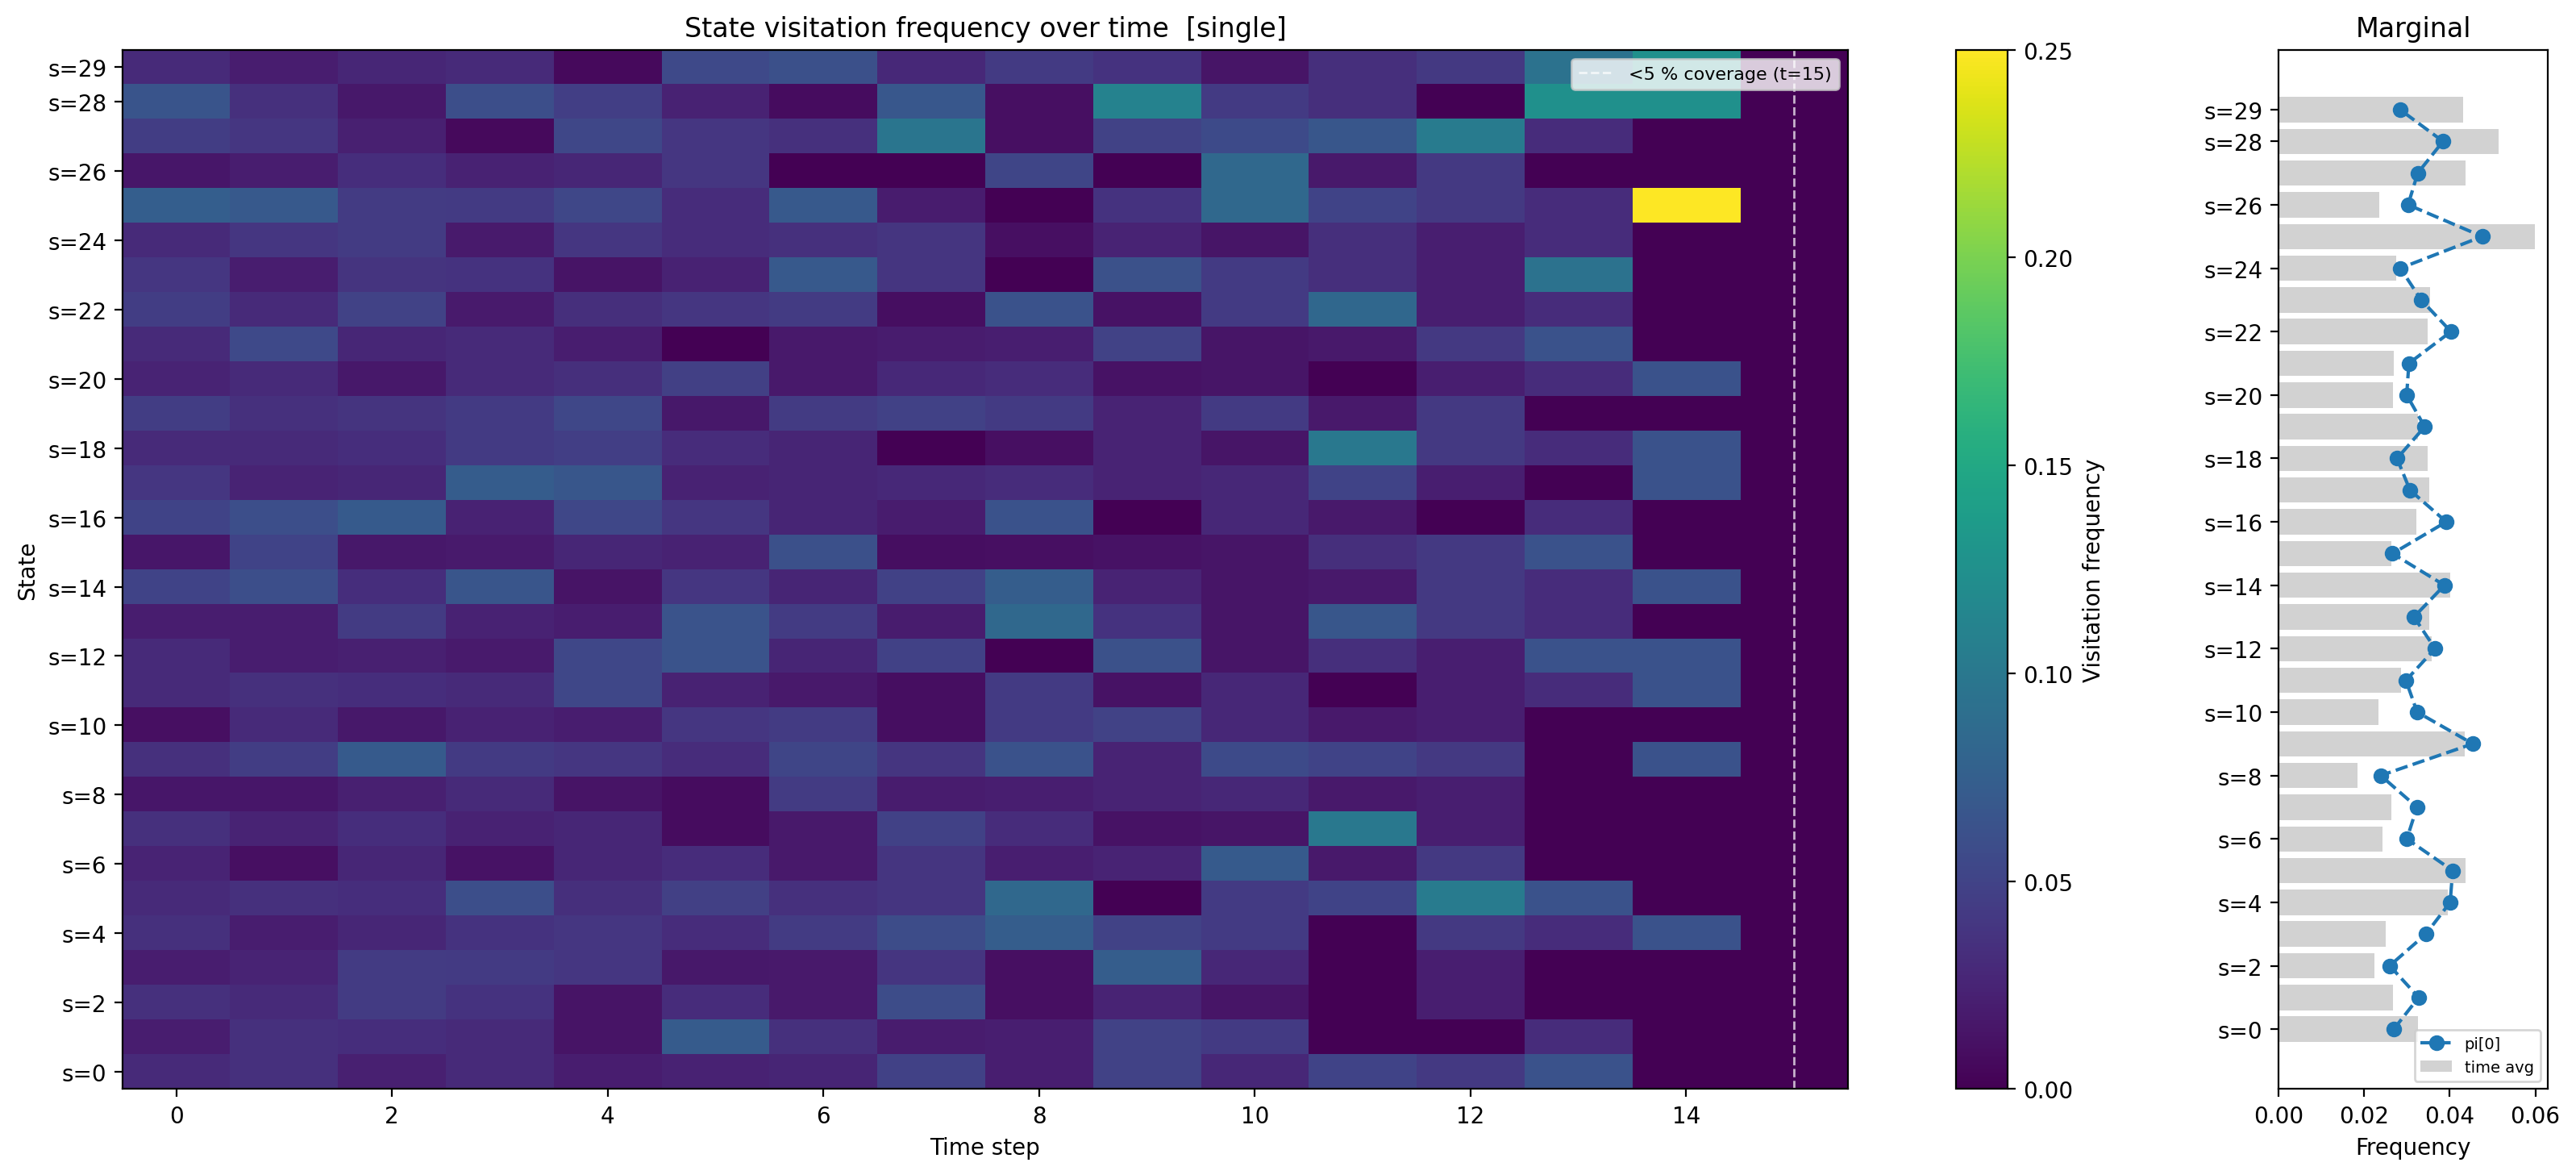

In [7]:
# State visitation frequency heatmap: rows = states, cols = time steps.
# For each time step t we count how many (non-PAD) sequences visit each state,
# then normalise so columns sum to 1. The expected pattern is that the
# empirical marginal at every t converges to a mixture of the stationary
# distributions (one per chain), not to any single one.

seqs_np = sequences.numpy()  # (N, L)
_, L = seqs_np.shape

freq = np.zeros((N_STATES, L), dtype=float)
n_valid_per_t = np.zeros(L, dtype=int)
for t in range(L):
    col = seqs_np[:, t]
    valid = col != PAD_ID
    n = int(valid.sum())
    n_valid_per_t[t] = n
    if n > 0:
        freq[:, t] = np.bincount(col[valid], minlength=N_STATES) / n

# Keep plots readable when N_STATES is large.
MAX_Y_TICKS = 20
TARGET_ROW_HEIGHT = 0.18
MIN_FIG_HEIGHT = 4.0
MAX_FIG_HEIGHT = 9.0

fig_height = float(
    np.clip(2.0 + N_STATES * TARGET_ROW_HEIGHT, MIN_FIG_HEIGHT, MAX_FIG_HEIGHT)
)
tick_step = max(1, int(np.ceil(N_STATES / MAX_Y_TICKS)))
yticks = np.arange(0, N_STATES, tick_step, dtype=int)
if len(yticks) == 0 or yticks[-1] != N_STATES - 1:
    yticks = np.append(yticks, N_STATES - 1)
ylabels = [f"s={s}" for s in yticks]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, fig_height),
    gridspec_kw={"width_ratios": [8, 1]},
)

# Main heatmap
ax = axes[0]
im = ax.imshow(
    freq,
    aspect="auto",
    origin="lower",
    cmap="viridis",
    extent=[-0.5, L - 0.5, -0.5, N_STATES - 0.5],
    vmin=0,
    vmax=freq.max(),
)
fig.colorbar(im, ax=ax, label="Visitation frequency")
ax.set_xlabel("Time step")
ax.set_ylabel("State")
ax.set_title(f"State visitation frequency over time  [{DGP_REGIME}]")
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)

# Mark where sequence coverage drops to <5 % of the dataset
cutoff = np.searchsorted(-n_valid_per_t, -int(0.05 * len(sequences)))
if cutoff < L:
    ax.axvline(
        cutoff,
        color="white",
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        label=f"<5 % coverage (t={cutoff})",
    )
    ax.legend(fontsize=8, loc="upper right")

# Right panel: marginal (time-avg) vs stationary dists
ax2 = axes[1]
active = n_valid_per_t > 0
time_avg = freq[:, active].mean(axis=1)

ax2.barh(range(N_STATES), time_avg, color="gray", alpha=0.35, label="time avg")
prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for k in range(N_CHAINS):
    ax2.plot(
        pis[k],
        range(N_STATES),
        "o--",
        color=prop_cycle[k],
        linewidth=1.5,
        label=f"pi[{k}]",
    )

if N_CHAINS > 1:
    mixture = pis.mean(axis=0)
    ax2.plot(
        mixture, range(N_STATES), "s:", color="black", linewidth=1.5, label="avg(pi)"
    )

ax2.set_xlabel("Frequency")
ax2.set_title("Marginal")
ax2.set_yticks(yticks)
ax2.set_yticklabels(ylabels)
ax2.legend(fontsize=7, loc="lower right")

plt.tight_layout()
plt.show()

## Save to disk


In [8]:
save_path = DATA_DIR / "sequences.pt"

torch.save(
    {
        "sequences": sequences,
        "Ts": torch.tensor(Ts, dtype=torch.float32),
        "pis": torch.tensor(pis, dtype=torch.float32),
        "chain_to_sample": torch.tensor(chain_to_sample, dtype=torch.long),
        "seq_lengths": torch.tensor(seqs_lengths, dtype=torch.long),
        "config": {
            "N": N_SEQUENCES,
            "L": MAX_SEQ_LEN,
            "seed": SEED,
            "n_chains": N_CHAINS,
            "n_states": N_STATES,
            "alpha": ALPHA,
            "pad_id": PAD_ID,
            "dgp_regime": DGP_REGIME,
        },
    },
    save_path,
)
print(f"Saved -> {save_path}  ({save_path.stat().st_size / 1024:.1f} KB)")

Saved -> /Users/ashrafahmed/workspace/slt-deep/projects/markov-chain-learning/experiments/two-mixed-chains/data/single/sequences.pt  (34.9 KB)


Per-chain empirical start probs vs stationary pi:
  chain 0: emp=[0.03  0.02  0.035 0.02  0.035 0.03  0.025 0.035 0.015 0.035 0.01  0.03
 0.03  0.02  0.05  0.015 0.05  0.04  0.03  0.045 0.025 0.03  0.045 0.04
 0.03  0.075 0.015 0.045 0.065 0.03 ]  pi=[0.027 0.033 0.026 0.034 0.04  0.041 0.03  0.032 0.024 0.045 0.032 0.03
 0.037 0.032 0.039 0.027 0.039 0.031 0.028 0.034 0.03  0.03  0.04  0.033
 0.028 0.048 0.03  0.033 0.038 0.028]

Overall empirical start probs: [0.03  0.02  0.035 0.02  0.035 0.03  0.025 0.035 0.015 0.035 0.01  0.03
 0.03  0.02  0.05  0.015 0.05  0.04  0.03  0.045 0.025 0.03  0.045 0.04
 0.03  0.075 0.015 0.045 0.065 0.03 ]
Overall expected (mixture):  [0.027 0.033 0.026 0.034 0.04  0.041 0.03  0.032 0.024 0.045 0.032 0.03
 0.037 0.032 0.039 0.027 0.039 0.031 0.028 0.034 0.03  0.03  0.04  0.033
 0.028 0.048 0.03  0.033 0.038 0.028]


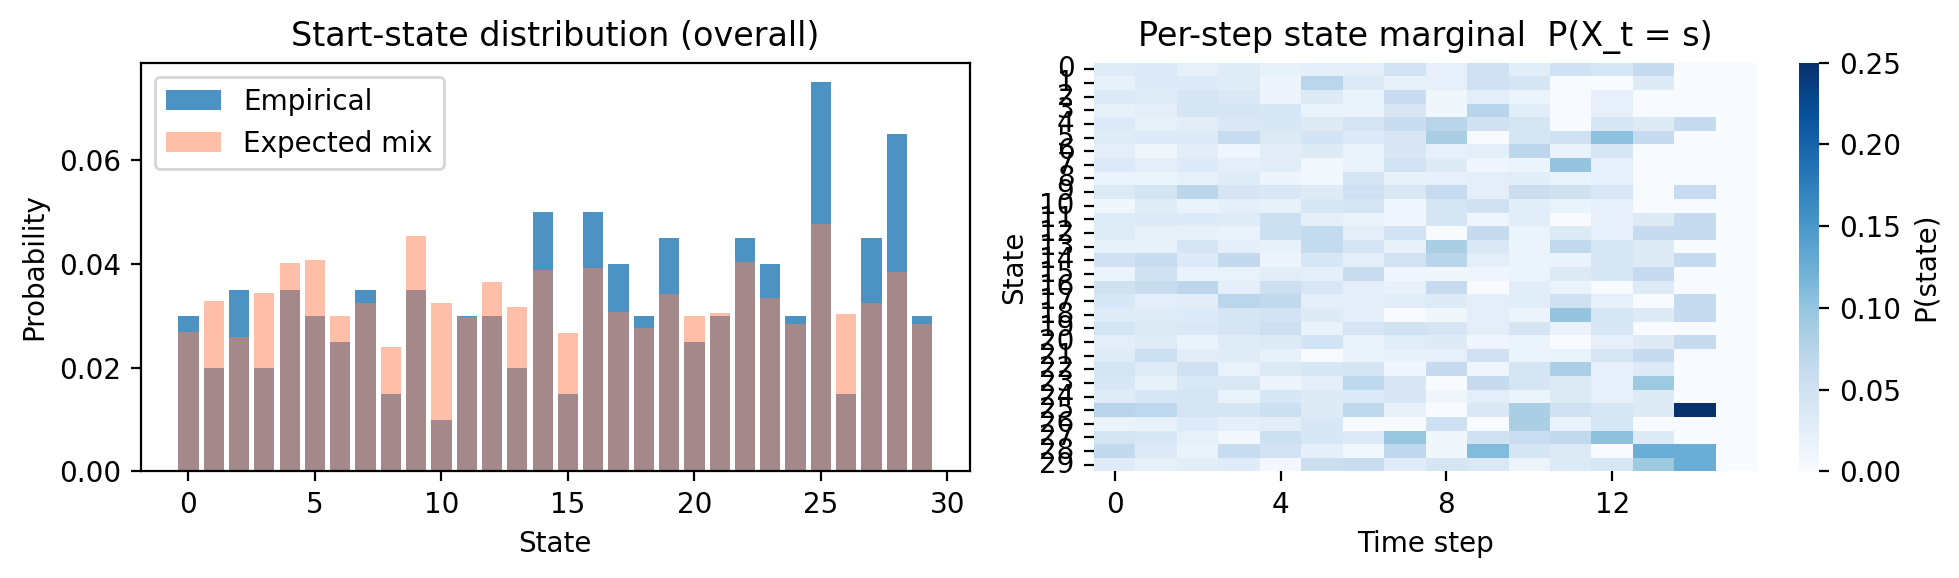

In [9]:
# Start-state verification against multiple stationary distributions.
start_tokens = sequences[:, 0]
valid_start = start_tokens != PAD_ID

chain_ids = torch.from_numpy(chain_to_sample).long()
emp_pi_by_chain = np.zeros((N_CHAINS, N_STATES), dtype=float)

for k in range(N_CHAINS):
    mask_k = valid_start & (chain_ids == k)
    if mask_k.any():
        counts_k = torch.bincount(start_tokens[mask_k], minlength=N_STATES).float()
        emp_pi_by_chain[k] = (counts_k / counts_k.sum()).numpy()

print("Per-chain empirical start probs vs stationary pi:")
for k in range(N_CHAINS):
    print(
        f"  chain {k}: emp={np.round(emp_pi_by_chain[k], 3)}  pi={np.round(pis[k], 3)}"
    )

# Aggregate expected start distribution is a mixture of chain-specific pi's.
chain_weights = np.bincount(chain_to_sample, minlength=N_CHAINS).astype(float)
chain_weights /= chain_weights.sum()
pi_mix = chain_weights @ pis

start_counts = torch.bincount(start_tokens[valid_start], minlength=N_STATES).float()
emp_mix = (start_counts / start_counts.sum()).numpy()

print("\nOverall empirical start probs:", np.round(emp_mix, 3))
print("Overall expected (mixture): ", np.round(pi_mix, 3))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Bar chart: overall empirical start-state vs expected mixture.
axes[0].bar(range(N_STATES), emp_mix, label="Empirical", alpha=0.8)
axes[0].bar(range(N_STATES), pi_mix, alpha=0.5, label="Expected mix", color="coral")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Probability")
axes[0].set_title("Start-state distribution (overall)")
axes[0].legend()

# Per-step state marginals (heatmap: state x time), ignoring PAD_ID tokens.
marginals = torch.zeros(N_STATES, MAX_SEQ_LEN)
for t in range(MAX_SEQ_LEN):
    token_t = sequences[:, t]
    valid_t = token_t != PAD_ID
    if valid_t.any():
        counts = torch.bincount(token_t[valid_t], minlength=N_STATES).float()
        marginals[:, t] = counts / counts.sum()

sns.heatmap(
    marginals.numpy(),
    ax=axes[1],
    cmap="Blues",
    xticklabels=4,
    yticklabels=range(N_STATES),
    cbar_kws={"label": "P(state)"},
)
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("State")
axes[1].set_title("Per-step state marginal  P(X_t = s)")

plt.tight_layout()
plt.show()

## Dataset & DataLoader


In [10]:
class MarkovSequenceDataset(Dataset):
    """Wraps a (N, L) LongTensor of Markov chain sequences."""

    def __init__(self, sequences: torch.Tensor):
        self.data = sequences

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> torch.Tensor:
        return self.data[idx]


dataset = MarkovSequenceDataset(sequences)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

# Sanity check: one batch
batch = next(iter(loader))
print(f"One batch: {batch.shape}  dtype={batch.dtype}")

One batch: torch.Size([200, 16])  dtype=torch.int64
